# Bicycle Theft Recovery Prediction using Machine Learning

Bicycle theft is a common urban crime in Toronto. However, only a small percentage of stolen bicycles are recovered.

The objective of this project is to build machine learning models to predict whether a stolen bicycle will be recovered based on theft characteristics.

We also address class imbalance using SMOTEENN and compare model performance before and after applying it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN

In [2]:
df = pd.read_csv("bicycle-thefts - 4326.csv")
df.head()

,_id,EVENT_UNIQUE_ID,PRIMARY_OFFENCE,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DOW,OCC_DAY,OCC_DOY,OCC_HOUR,...,BIKE_MAKE,BIKE_MODEL,BIKE_TYPE,BIKE_SPEED,BIKE_COLOUR,BIKE_COST,STATUS,LONG_WGS84,LAT_WGS84,geometry
0,1,GO-20141263544,B&E,2013-12-26,2013,December,Thursday,26,360,19,...,FELT,F59,RC,21.0,SILRED,1300.0,STOLEN,-79.395643,43.640021,"{""coordinates"": [[-79.395642735, 43.640020679]..."
1,2,GO-20141261431,THEFT UNDER,2014-01-01,2014,January,Wednesday,1,1,7,...,SUPERCYCLE,NaN,MT,10.0,NaN,NaN,STOLEN,-79.443645,43.637657,"{""coordinates"": [[-79.4436451189999, 43.637657..."
2,3,GO-20141263784,PROPERTY - FOUND,2014-01-01,2014,January,Wednesday,1,1,18,...,TREK,SOHO S,RG,1.0,BLK,NaN,RECOVERED,-79.414654,43.660525,"{""coordinates"": [[-79.41465353, 43.66052480500..."
3,4,GO-20149000090,THEFT UNDER,2014-01-01,2014,January,Wednesday,1,1,12,...,GI,TCX2 (2010),OT,9.0,BLU,1019.0,STOLEN,-79.393760,43.642772,"{""coordinates"": [[-79.393760036, 43.642772182]..."
4,5,GO-20149000071,THEFT UNDER,2013-12-25,2013,December,Wednesday,25,359,10,...,BI,NaN,TO,25.0,RED,400.0,STOLEN,-79.373767,43.667288,"{""coordinates"": [[-79.3737671549999, 43.667288..."


## Data Understanding

The dataset contains information about bicycle theft incidents including:
- Time of theft (year, month, hour)
- Location details
- Bicycle characteristics
- Recovery status

The target variable is `STATUS`, which indicates whether the bicycle was recovered or not.

## Target Variable Processing

We remove 'UNKNOWN' values and convert the STATUS column into a binary variable:
- 1 → Recovered
- 0 → Stolen

In [3]:
df = df[df['STATUS'] != 'UNKNOWN']

df['STATUS'] = df['STATUS'].map({
    'RECOVERED': 1,
    'STOLEN': 0
})

df['STATUS'].value_counts()

STATUS
0    38797
1      401
Name: count, dtype: int64

## Data Cleaning

Irrelevant and high-cardinality columns are removed to reduce dimensionality and improve model performance.

In [4]:
df = df.drop(columns=[
    'EVENT_UNIQUE_ID',
    'geometry',
    'BIKE_MODEL',
    'BIKE_COLOUR',
    'LAT_WGS84',
    'LONG_WGS84'
], errors='ignore')

## Handling Missing Values

- Numerical features are filled using median
- Categorical features are filled using mode

In [5]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

## Exploratory Data Analysis (EDA)

## Recovery Distribution

This graph shows the distribution of stolen vs recovered bicycles.

The dataset is highly imbalanced, with a significantly larger number of stolen bicycles compared to recovered ones. This imbalance can negatively affect model performance, as models may become biased toward predicting the majority class.

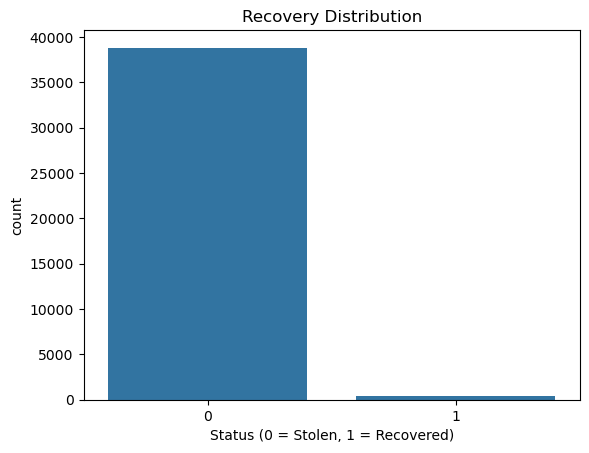

In [6]:
sns.countplot(x='STATUS', data=df)
plt.title("Recovery Distribution")
plt.xlabel("Status (0 = Stolen, 1 = Recovered)")
plt.show()

## Recovery vs Time of Theft

This graph analyzes how the hour of theft impacts recovery.

The results suggest that theft timing influences recovery probability. Certain hours, especially late-night periods, tend to have lower recovery rates, possibly due to reduced visibility and delayed reporting.

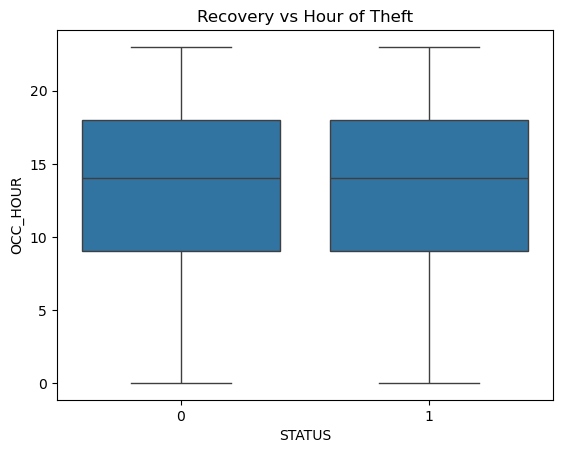

In [7]:
sns.boxplot(x='STATUS', y='OCC_HOUR', data=df)
plt.title("Recovery vs Hour of Theft")
plt.show()

## Bike Cost vs Recovery

This graph examines the relationship between bicycle cost and recovery status.

Higher-cost bicycles appear to have lower recovery rates. This may be because expensive bicycles are more attractive targets and are quickly resold, making recovery more difficult.

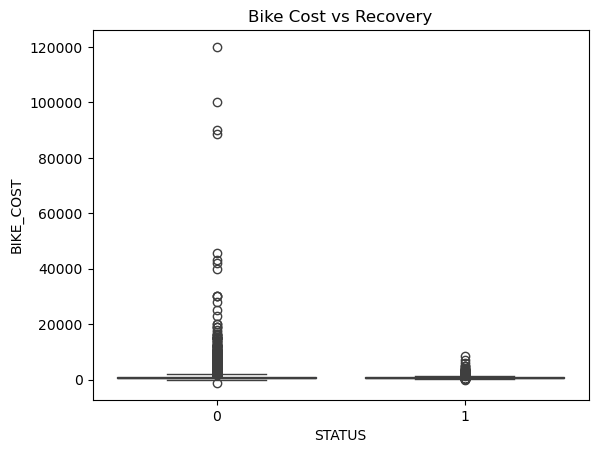

In [8]:
sns.boxplot(x='STATUS', y='BIKE_COST', data=df)
plt.title("Bike Cost vs Recovery")
plt.show()

## Recovery by Premises Type

This graph shows how recovery varies across different location types.

Recovery rates differ significantly depending on the premises type. Residential and apartment areas tend to show lower recovery rates compared to commercial or public locations.

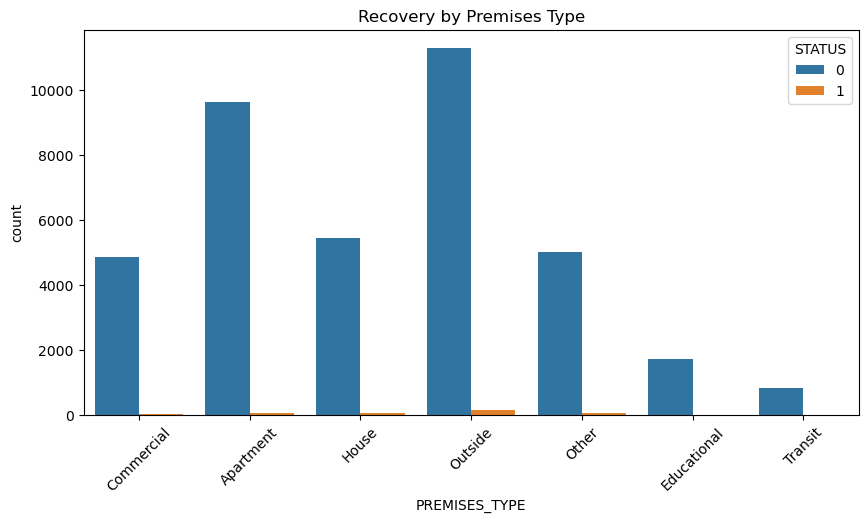

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='PREMISES_TYPE', hue='STATUS', data=df)
plt.xticks(rotation=45)
plt.title("Recovery by Premises Type")
plt.show()

## Feature Engineering

We create new features:
- IS_WEEKEND: Whether theft occurred on weekend
- IS_NIGHT: Whether theft occurred at night

## Encoding

Categorical variables are converted into numerical format using one-hot encoding.
This avoids introducing artificial ordinal relationships.

In [10]:
df['IS_WEEKEND'] = df['OCC_DOW'].isin(['Saturday', 'Sunday']).astype(int)

df['IS_NIGHT'] = df['OCC_HOUR'].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)

## Weekend vs Weekday Recovery

This graph compares recovery rates between weekends and weekdays.

The results indicate that theft patterns differ between weekends and weekdays. Weekend thefts may have slightly different recovery behavior due to changes in activity levels and reporting patterns.

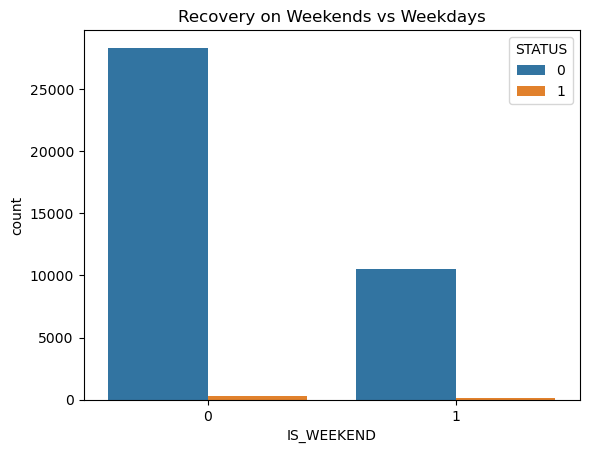

In [11]:
sns.countplot(x='IS_WEEKEND', hue='STATUS', data=df)
plt.title("Recovery on Weekends vs Weekdays")
plt.show()

## Night vs Day Recovery

This graph compares recovery rates for thefts occurring at night versus during the day.

Night-time thefts are less likely to be recovered. This suggests that reduced visibility and delayed detection may make recovery more difficult.

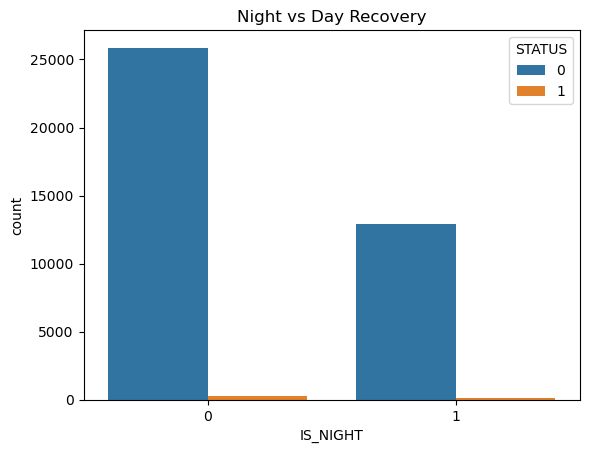

In [12]:
sns.countplot(x='IS_NIGHT', hue='STATUS', data=df)
plt.title("Night vs Day Recovery")
plt.show()

In [13]:
X = df.drop('STATUS', axis=1)
y = df['STATUS']

X = pd.get_dummies(X, drop_first=True)
X = X.astype('float32')

X.shape

(39198, 9928)

## Train-Test Split

The dataset is split into training and testing sets for evaluation.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Selection

We use four models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

In [15]:
models = {
    "Logistic": LogisticRegression(max_iter=2000, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

## Baseline Model Performance

Models are first trained on the imbalanced dataset without applying SMOTEENN.

In [16]:
X_train_small = X_train.sample(frac=0.3, random_state=42)
y_train_small = y_train.loc[X_train_small.index]
y_train_small = y_train.loc[X_train_small.index]

baseline_results = {}

for name, model in models.items():
    model.fit(X_train_small, y_train_small)
    y_pred = model.predict(X_test)

    baseline_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

baseline_df = pd.DataFrame(baseline_results).T
baseline_df

,Accuracy,Precision,Recall,F1
Logistic,0.989668,0.000000,0.000000,0.000000
Decision Tree,0.983546,0.184211,0.172840,0.178344
Random Forest,0.989541,0.000000,0.000000,0.000000
XGBoost,0.990689,0.833333,0.123457,0.215054


## Handling Class Imbalance

SMOTEENN is applied to balance the dataset by oversampling the minority class and removing noise.

In [17]:
X_train_small = X_train.sample(frac=0.4, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

smoteenn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smoteenn.fit_resample(X_train_small, y_train_small)

## Model Performance After SMOTEENN

Models are retrained on balanced data to improve minority class prediction.

In [18]:
results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1
Logistic,0.955485,0.075949,0.296296,0.120907
Decision Tree,0.983418,0.211765,0.222222,0.216867
Random Forest,0.989541,0.333333,0.012346,0.023810
XGBoost,0.990944,0.708333,0.209877,0.323810


## Model Performance Comparison

This graph compares the performance of different models using key evaluation metrics.

XGBoost and Random Forest outperform simpler models such as Logistic Regression. Additionally, recall and F1-score improved significantly after applying SMOTEENN, highlighting the importance of handling class imbalance.

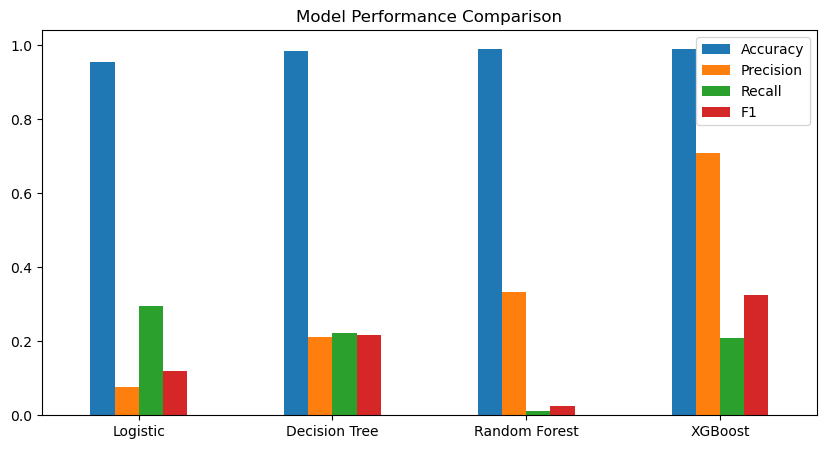

In [19]:
results_df[['Accuracy','Precision','Recall','F1']].plot(kind='bar', figsize=(10,5))
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.show()

## Confusion Matrix

The confusion matrix shows how well the model predicts each class.

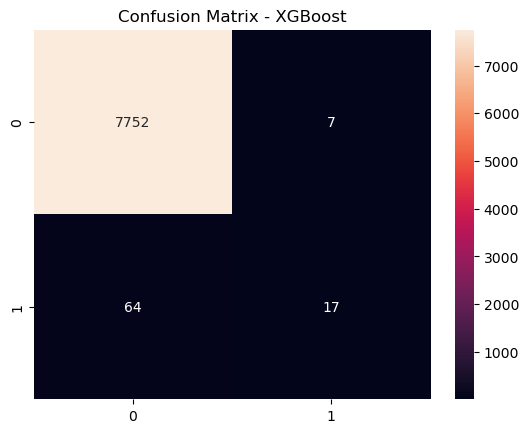

In [20]:
y_pred_xgb = models["XGBoost"].predict(X_test)

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()

## Feature Importance

XGBoost feature importance helps identify key factors affecting bicycle recovery.

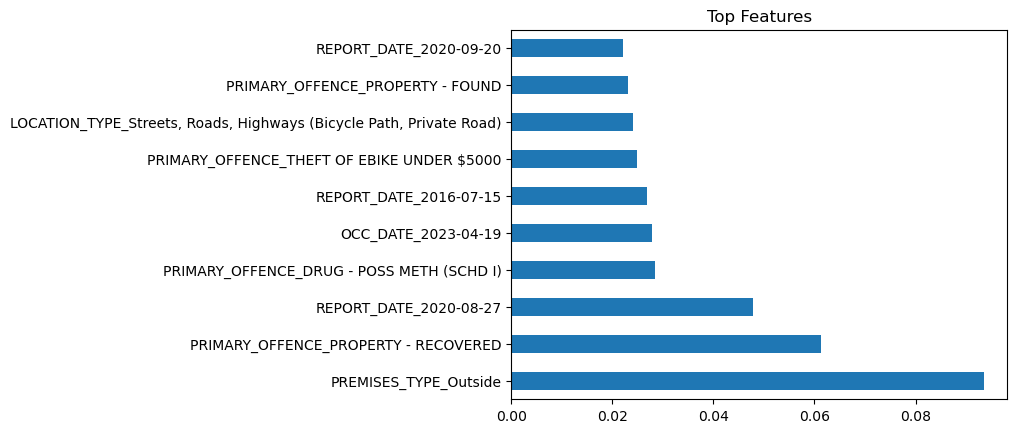

In [21]:
xgb = models["XGBoost"]

importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()


This graph shows the most important features influencing bicycle recovery.

Key factors include time of theft, location type, and bicycle characteristics. This indicates that both environmental and contextual factors play a significant role in recovery outcomes.

## Key Insights

- The dataset is highly imbalanced, making accuracy a misleading metric  
- Baseline models failed to detect recovered bicycles  
- SMOTEENN significantly improved recall and F1-score  
- XGBoost performed best due to its ability to capture complex patterns  

### High-Risk Theft Scenario

A bicycle is least likely to be recovered if:
- Theft occurs at night  
- The bicycle is high-value  
- Theft occurs in residential or apartment areas  

These insights can help improve theft prevention strategies and resource allocation.